In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV

#### Load cleaned data

In [299]:
df = pd.read_csv('data/f1_laps_clean.csv')

In [300]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint',
       'LapTime', 'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean',
       'Gear_Mean', 'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

#### Filter out wet tyres

In [301]:
df['Rainfall'].value_counts()

Rainfall
False    78539
True      3662
Name: count, dtype: int64

In [302]:
df[df['Rainfall']==1]['Compound'].value_counts()

Compound
INTERMEDIATE    2337
MEDIUM           445
HARD             421
SOFT             349
WET              110
Name: count, dtype: int64

In [303]:
df['Compound'].value_counts()

Compound
HARD            37613
MEDIUM          29325
SOFT            10292
INTERMEDIATE     4834
WET               137
Name: count, dtype: int64

In [304]:
df[(df['Compound']=='INTERMEDIATE') | (df['Compound']=='WET')]['Rainfall'].value_counts()

Rainfall
False    2524
True     2447
Name: count, dtype: int64

In [305]:
df = df[~((df['Compound']=='INTERMEDIATE') | (df['Compound']=='WET'))]

In [306]:
df['Rainfall'].value_counts()

Rainfall
False    76015
True      1215
Name: count, dtype: int64

In [307]:
df['Compound'].value_counts()

Compound
HARD      37613
MEDIUM    29325
SOFT      10292
Name: count, dtype: int64

#### Encode and standardize features

In [308]:
df.dtypes

Driver                 object
Team                   object
Year                    int64
Race                   object
Sector1Time            object
Sector2Time            object
Sector3Time            object
Sector1SessionTime     object
Sector2SessionTime     object
Sector3SessionTime     object
SpeedI1               float64
SpeedI2               float64
SpeedFL               float64
Stint                 float64
LapTime                object
LapNumber             float64
Position              float64
Compound               object
TyreLife              float64
FreshTyre                bool
TrackStatus             int64
AirTemp               float64
Humidity              float64
Pressure              float64
Rainfall                 bool
TrackTemp             float64
WindDirection         float64
WindSpeed             float64
Speed_Mean            float64
Speed_Max             float64
Speed_Std             float64
RPM_Mean              float64
Throttle_Mean         float64
Throttle_S

In [309]:
# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

In [310]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

categorical_cols = ['Driver', 'Team', 'Race', 'TrackStatus', 'Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'RPM_Mean', 'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct']

In [311]:
df_encoded = df.copy()

In [312]:
# Apply cyclical encoding
df_encoded['WindDir_sin'] = np.sin(np.deg2rad(df_encoded['WindDirection']))
df_encoded['WindDir_cos'] = np.cos(np.deg2rad(df_encoded['WindDirection']))

df_encoded = df_encoded.drop(columns=['WindDirection'])

In [313]:
# Label encode
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le


In [314]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint',
       'LapTime', 'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit', 'WindDir_sin',
       'WindDir_cos'],
      dtype='object')

In [315]:
df_encoded.loc[0]

Driver                                    28
Team                                      11
Year                                    2022
Race                                       4
Sector1Time                              NaN
Sector2Time           0 days 00:00:42.325000
Sector3Time           0 days 00:00:24.389000
Sector1SessionTime                       NaN
Sector2SessionTime    0 days 01:03:51.046000
Sector3SessionTime    0 days 01:04:15.427000
SpeedI1                                230.0
SpeedI2                                254.0
SpeedFL                                274.0
Stint                                    1.0
LapTime               0 days 00:01:40.236000
LapNumber                                1.0
Position                                 2.0
Compound                                   2
TyreLife                                 4.0
FreshTyre                                  0
TrackStatus                                0
AirTemp                                 23.9
Humidity  

In [ ]:
# Convert LapTime to seconds
df_encoded['LapTimeSeconds'] = pd.to_timedelta(df_encoded['LapTime']).dt.total_seconds()
df_encoded = df_encoded.drop(columns=['LapTime'])

df_encoded['LapTimeSeconds']

0        100.236
1        101.006
2        108.826
3        104.270
4        101.555
          ...   
82196     79.675
82197     80.110
82198     79.899
82199     81.201
82200     79.978
Name: LapTimeSeconds, Length: 77230, dtype: float64

In [ ]:
# Convert LapTime to seconds
sector_times = ['Sector1Time', 'Sector2Time', 'Sector3Time',
                'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime']

for col in sector_times:
    df_encoded[col] = pd.to_timedelta(df_encoded[col]).dt.total_seconds()

df_encoded[sector_times]

,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime
0,NaN,42.325,24.389,NaN,3831.046,3855.427
1,NaN,42.889,24.253,NaN,3831.952,3856.235
2,NaN,47.568,24.968,NaN,3839.068,3864.062
3,NaN,44.153,24.667,NaN,3834.779,3859.464
4,NaN,42.966,24.137,NaN,3832.639,3856.785
...,...,...,...,...,...,...
82196,23.435,32.304,23.936,9101.859,9134.163,9158.099
82197,23.487,32.417,24.206,9103.230,9135.647,9159.853
82198,23.117,32.742,24.040,9103.584,9136.326,9160.366
82199,24.244,32.673,24.284,9106.283,9138.956,9163.240


In [319]:
df_encoded[sector_times].isnull().sum()

Sector1Time           1379
Sector2Time             24
Sector3Time             37
Sector1SessionTime    1562
Sector2SessionTime      24
Sector3SessionTime      37
dtype: int64

In [320]:
# Standardize numerical columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [322]:
df_encoded[numerical_cols].describe()

,LapTimeSeconds,LapNumber,TyreLife,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,...,Speed_Mean,Speed_Max,Speed_Std,Throttle_Mean,Throttle_Std,RPM_Mean,Brake_Mean,Gear_Mean,Distance_Total,DRS_active_pct
count,7.723000e+04,7.723000e+04,7.723000e+04,7.585100e+04,7.720600e+04,7.719300e+04,7.566800e+04,7.720600e+04,7.719300e+04,6.521800e+04,...,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04,7.723000e+04
mean,3.753741e-16,9.126743e-17,3.606536e-17,-1.918487e-16,4.358638e-16,5.213574e-16,4.236889e-16,-4.204025e-16,5.434488e-16,1.185364e-16,...,1.707584e-16,-8.125746e-16,-1.162924e-15,3.061875e-16,4.857783e-16,-9.568360e-16,-2.944111e-17,-1.171756e-15,-2.001995e-16,2.944111e-17
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000007e+00,1.000006e+00,1.000006e+00,1.000007e+00,1.000006e+00,1.000006e+00,1.000008e+00,...,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-6.713135e-01,-1.641923e+00,-1.284381e+00,-1.692242e+00,-2.383627e+00,-1.554976e+00,-2.999606e+00,-2.992689e+00,-2.989612e+00,-4.345358e+00,...,-7.761995e+00,-1.699752e+01,-7.667140e+00,-6.456676e+00,-1.724842e+01,-2.088515e+01,-4.364664e+00,-7.042195e+00,-6.119269e+00,-5.859928e-01
25%,-2.835464e-01,-8.674148e-01,-7.178166e-01,-6.161843e-01,-6.849670e-01,-6.455383e-01,-7.945565e-01,-7.950094e-01,-7.954044e-01,-8.138171e-01,...,-4.823662e-01,-4.885660e-01,-6.672243e-01,-4.305339e-01,-3.749849e-01,-4.370944e-01,-6.973330e-01,-4.351060e-01,-8.638619e-01,-5.859928e-01
50%,-5.276411e-02,-3.758431e-02,-2.456798e-01,3.525989e-02,-2.312246e-01,-2.633786e-01,-4.850358e-02,-4.335504e-02,-4.360153e-02,3.843842e-01,...,9.492367e-02,-4.978984e-02,-1.478645e-01,1.563374e-01,2.278119e-01,1.459949e-01,-5.941832e-02,1.414740e-01,2.464312e-01,-5.859928e-01
75%,1.854815e-01,7.922462e-01,5.097389e-01,4.503859e-01,7.416245e-01,4.602283e-01,7.036722e-01,7.088166e-01,7.078891e-01,7.207214e-01,...,7.077038e-01,6.632214e-01,6.294811e-01,6.589828e-01,6.327364e-01,6.687319e-01,5.519775e-01,6.736772e-01,7.875789e-01,2.430254e-01
max,6.558860e+01,2.617873e+00,5.986525e+00,9.320565e+00,7.522389e+00,8.471539e+00,4.547984e+00,4.519518e+00,4.528012e+00,2.192197e+00,...,2.202165e+00,3.241031e+00,5.370044e+00,4.414863e+00,3.963568e+00,3.305512e+00,1.694078e+01,4.552014e+01,2.520886e+00,7.867480e+00


#### Split into train, val, and test sets

In [334]:
df_encoded_copy = df_encoded.copy()

In [335]:
# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_encoded_copy['PitNext5'] = (df_encoded_copy['LapsTilPit'] <= 5).astype(int)

In [336]:
df_encoded_copy['PitNext5'].value_counts()

PitNext5
0    59250
1    17980
Name: count, dtype: int64

In [337]:
# Train, val, test split
train_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
val_df_cl   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [338]:
# Split sets into features and target
feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Training set
X_train_cl = train_df_cl[feature_cols]
y_train_cl = train_df_cl['PitNext5']

# Validation set
X_val_cl = val_df_cl[feature_cols]
y_val_cl = val_df_cl['PitNext5']

# Test set
X_test_cl = test_df_cl[feature_cols]
y_test_cl = test_df_cl['PitNext5']

In [339]:
print(X_train_cl.shape)
print(y_train_cl.shape)
print(X_val_cl.shape)
print(y_val_cl.shape)
print(X_test_cl.shape)
print(y_test_cl.shape)

(44866, 38)
(44866,)
(24206, 38)
(24206,)
(8158, 38)
(8158,)


#### Train XGBoost classifier model

In [340]:
# Train
xgb_base = XGBClassifier()
xgb_base.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cl = xgb_base.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

XGBoost Classifier Validation Set Performance:

[[16941  1843]
 [ 2381  3041]]
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     18784
           1       0.62      0.56      0.59      5422

    accuracy                           0.83     24206
   macro avg       0.75      0.73      0.74     24206
weighted avg       0.82      0.83      0.82     24206



#### Tune classifier model

##### RandomSearch tuning

In [341]:
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

In [349]:
search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=72,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=111
)
search.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=72,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.1],
                                        'max_depth': [4, 6, 8],
                                        'n_estimators': [100, 200, 400],
                                        'subsample': [0.8, 1.0]},
                   random_state=111, scoring='f1', verbose=1)

In [350]:
best_xgb_cl = search.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print(search.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

{'subsample': 0.8, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
[[16912  1872]
 [ 2319  3103]]
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     18784
           1       0.62      0.57      0.60      5422

    accuracy                           0.83     24206
   macro avg       0.75      0.74      0.74     24206
weighted avg       0.82      0.83      0.82     24206



##### Manual Training

In [472]:
# Train
xgb_tuned = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=111,
)
xgb_tuned.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_tuned = xgb_tuned.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_tuned), "\n")
print(classification_report(y_val_cl, y_val_pred_tuned))

XGBoost Classifier Validation Set Performance:

[[17006  1778]
 [ 2297  3125]] 

              precision    recall  f1-score   support

           0       0.88      0.91      0.89     18784
           1       0.64      0.58      0.61      5422

    accuracy                           0.83     24206
   macro avg       0.76      0.74      0.75     24206
weighted avg       0.83      0.83      0.83     24206



#### Adjust features set

##### Keep session and weather data

In [390]:
df_encoded_copy.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint',
       'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit', 'WindDir_sin',
       'WindDir_cos', 'LapTimeSeconds', 'PitNext5'],
      dtype='object')

In [391]:
df_public = df_encoded_copy.copy()

In [392]:
# Keep features only available to other teams
features_to_keep = ['Driver', 'Team', 'Race',
                    'Sector1Time', 'Sector2Time', 'Sector3Time',
                    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
                    'SpeedI1', 'SpeedI2', 'SpeedFL',
                    'LapNumber', 'Position', 'Compound', 'TrackStatus',
                    'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
                    'TrackTemp', 'WindSpeed', 'WindDir_sin', 'WindDir_cos',
                    'LapTimeSeconds']

year = ['Year']
label = ['PitNext5']

In [393]:
df_public = df_public[features_to_keep + year + label]

##### Split

In [394]:
# Train, val, test split
train_df = df_public[df_public['Year'].isin([2022, 2023])]
val_df   = df_public[df_public['Year'] == 2024]
test_df  = df_public[df_public['Year'] == 2025]

In [395]:
# Training set
X_train = train_df[features_to_keep]
y_train = train_df[label]

# Validation set
X_val = val_df[features_to_keep]
y_val = val_df[label]

# Test set
X_test = test_df[features_to_keep]
y_test = test_df[label]

In [396]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(44866, 25)
(44866, 1)
(24206, 25)
(24206, 1)
(8158, 25)
(8158, 1)


##### Train

In [397]:
# Train
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Predict
y_val_pred = xgb.predict(X_val)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

XGBoost Classifier Validation Set Performance:

[[17568  1216]
 [ 3108  2314]]
              precision    recall  f1-score   support

           0       0.85      0.94      0.89     18784
           1       0.66      0.43      0.52      5422

    accuracy                           0.82     24206
   macro avg       0.75      0.68      0.70     24206
weighted avg       0.81      0.82      0.81     24206



##### RandomSearch tuning

In [398]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 3, 5],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.2]
}

In [399]:
search_p = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=72,
    scoring='f1',  # focus positive label
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=4
)
search_p.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=72, n_jobs=4,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'gamma': [0, 0.2],
                                        'learning_rate': [0.01, 0.1],
                                        'max_depth': [4, 8],
                                        'min_child_weight': [1, 3],
                                        'n_estimators': [100, 200],
                                        'scale_pos_weight': [1, 3, 5],
                                        'subsample': [0.8, 1.0]},
                   random_state=111, scoring='f1', verbose=1)

In [400]:
best_xgb = search_p.best_estimator_
y_val_pred_best = best_xgb.predict(X_val)

print(search.best_params_)
print(confusion_matrix(y_val, y_val_pred_best))
print(classification_report(y_val, y_val_pred_best))

{'subsample': 0.8, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
[[16370  2414]
 [ 2529  2893]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87     18784
           1       0.55      0.53      0.54      5422

    accuracy                           0.80     24206
   macro avg       0.71      0.70      0.70     24206
weighted avg       0.79      0.80      0.80     24206



##### Manual tuning

In [481]:
# Tune
xgb_t = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=111,
)
xgb_t.fit(X_train, y_train)

# Predict
y_val_pred_t = xgb_t.predict(X_val)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val, y_val_pred_t), "\n")
print(classification_report(y_val, y_val_pred_t))

XGBoost Classifier Validation Set Performance:

[[17832   952]
 [ 3183  2239]] 

              precision    recall  f1-score   support

           0       0.85      0.95      0.90     18784
           1       0.70      0.41      0.52      5422

    accuracy                           0.83     24206
   macro avg       0.78      0.68      0.71     24206
weighted avg       0.82      0.83      0.81     24206



In [491]:
# Tune
xgb_t = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=111,
    scale_pos_weight=3,
)
xgb_t.fit(X_train, y_train)

# Predict
y_val_pred_t = xgb_t.predict(X_val)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val, y_val_pred_t), "\n")
print(classification_report(y_val, y_val_pred_t))

XGBoost Classifier Validation Set Performance:

[[17651  1133]
 [ 2956  2466]] 

              precision    recall  f1-score   support

           0       0.86      0.94      0.90     18784
           1       0.69      0.45      0.55      5422

    accuracy                           0.83     24206
   macro avg       0.77      0.70      0.72     24206
weighted avg       0.82      0.83      0.82     24206



#### Exploring model results


--- WEIGHT ---


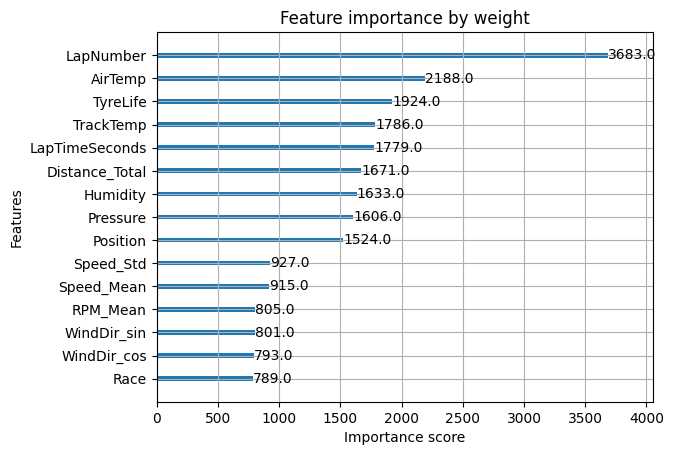


--- GAIN ---


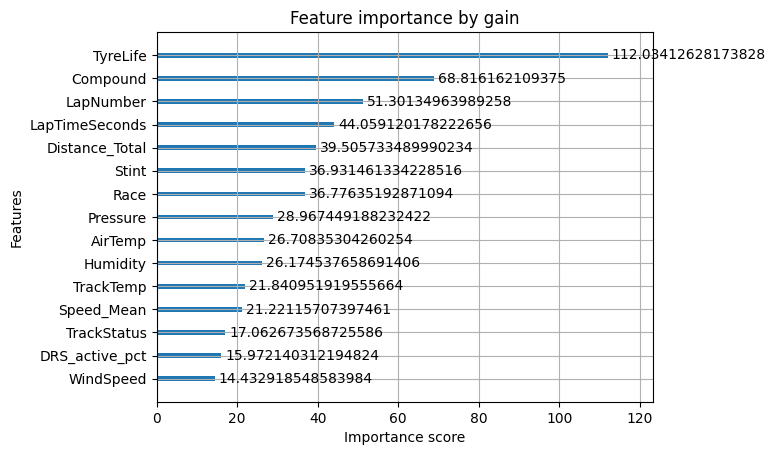


--- COVER ---


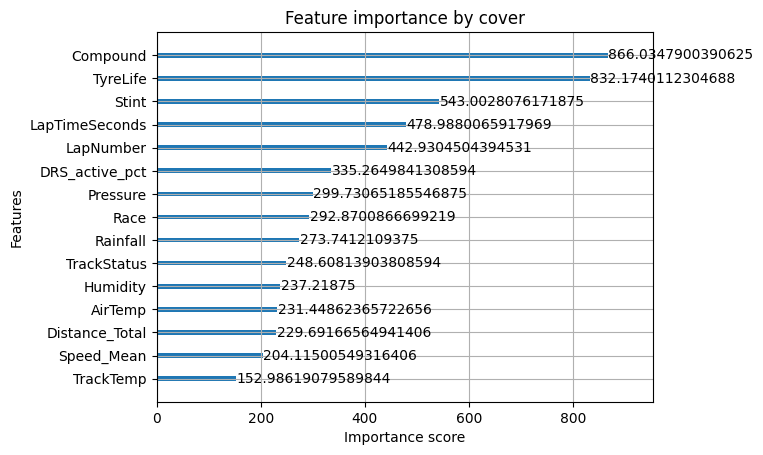

In [73]:
from xgboost import plot_importance

for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_cl, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()

Find false positive/negative laps:

In [74]:
# Add predictions and true labels back to validation set
val_results = X_val_cl.copy()
val_results['TrueLabel'] = y_val_cl.values  # true pit/npit
val_results['PredLabel'] = y_val_pred_cl_best
val_results['Correct'] = (val_results['TrueLabel'] == val_results['PredLabel'])

In [75]:
# Reverse categorical encoding
for col in categorical_cols:
    val_results[col] = encoders[col].inverse_transform(val_results[col])

In [76]:
# Reverse standardization
val_results[numerical_cols] = scaler.inverse_transform(val_results[numerical_cols])

In [ ]:
# Add LapsTilPit back in
val_results['LapsTilPit'] = val_df['LapsTilPit']

In [78]:
val_results.shape

(24206, 33)

In [79]:
val_results.iloc[600]

Driver                           SAI
Team                         Ferrari
Race              Bahrain Grand Prix
Stint                            2.0
LapNumber                       31.0
Position                         3.0
Compound                        HARD
TyreLife                        17.0
FreshTyre                          1
TrackStatus                        1
AirTemp                         18.0
Humidity                        49.0
Pressure                      1017.3
Rainfall                           0
TrackTemp                       22.6
WindSpeed                        0.8
Speed_Mean                199.893557
Speed_Max                      303.0
Speed_Std                  68.559208
RPM_Mean                10056.714286
Throttle_Mean              67.607843
Throttle_Std               41.866464
Brake_Mean                   0.22409
Gear_Mean                   5.221289
Distance_Total           5376.746111
DRS_active_pct                   0.0
WindDir_sin                 0.994522
W

In [80]:
# False Positives: Predicted 1 (pit soon), actually 0 (not pitting soon)
false_positives = val_results[(val_results['PredLabel'] == 1) & (val_results['TrueLabel'] == 0)]

# False Negatives: Predicted 0, actually 1
false_negatives = val_results[(val_results['PredLabel'] == 0) & (val_results['TrueLabel'] == 1)]

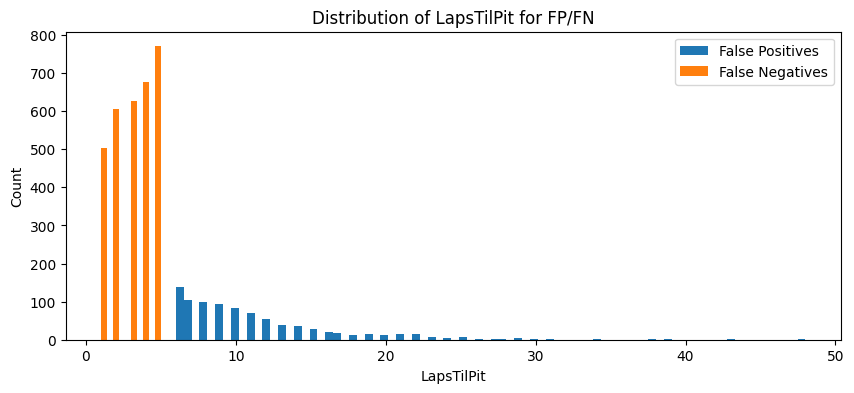

In [81]:
plt.figure(figsize=(10,4))
plt.hist(false_positives['LapsTilPit'], bins=80, label='False Positives')
plt.hist(false_negatives['LapsTilPit'], bins=10, label='False Negatives')
plt.xlabel('LapsTilPit')
plt.ylabel('Count')
plt.legend()
plt.title('Distribution of LapsTilPit for FP/FN')
plt.show()

In [82]:
# Mean TyreLife for FP/FN
print("False Positives: Mean TyreLife", false_positives['TyreLife'].mean())
print("False Negatives: Mean TyreLife", false_negatives['TyreLife'].mean())

False Positives: Mean TyreLife 23.466965285554313
False Negatives: Mean TyreLife 16.98868280414964


In [83]:
print('Stint Precision')
print(val_results.groupby('Stint')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Stint').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Stint').size())

Stint Precision
Stint
1.0    0.733723
2.0    0.874391
3.0    0.877853
4.0    0.854489
5.0    0.889908
Name: Correct, dtype: float64

False Positives
Stint
1.0    694
2.0    140
3.0     50
4.0      9
dtype: int64

False Negatives
Stint
1.0    1265
2.0    1200
3.0     560
4.0     132
5.0      24
dtype: int64


In [84]:
print('Compound Precision')
print(val_results.groupby('Compound')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Compound').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Compound').size())

Compound Precision
Compound
HARD      0.874022
MEDIUM    0.776958
SOFT      0.775912
Name: Correct, dtype: float64

False Positives
Compound
HARD      155
MEDIUM    716
SOFT       22
dtype: int64

False Negatives
Compound
HARD      1567
MEDIUM    1249
SOFT       365
dtype: int64


In [85]:
print('Rainfall Precision')
print(val_results.groupby('Rainfall')['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby('Rainfall').size())
print('\nFalse Negatives')
print(false_negatives.groupby('Rainfall').size())

Rainfall Precision
Rainfall
0    0.833882
1    0.550802
Name: Correct, dtype: float64

False Positives
Rainfall
0    855
1     38
dtype: int64

False Negatives
Rainfall
0    3135
1      46
dtype: int64


In [86]:
print('TrackStatus Precision')
print(val_results.groupby('TrackStatus')['Correct'].agg(['count', 'mean']))

TrackStatus Precision
             count      mean
TrackStatus                 
1            22841  0.834158
12             414  0.799517
124             89  0.752809
125             18  0.444444
1254            16  0.125000
126             38  0.894737
1264            15  0.866667
1267             9  0.888889
14              17  0.647059
16              17  0.705882
167             22  0.772727
21              32  0.937500
24              34  0.617647
26              35  0.542857
2671             1  1.000000
4              363  0.845730
41             146  0.938356
412              1  0.000000
6               26  0.538462
64              19  0.263158
671             43  0.860465
71              10  0.500000


In [87]:
precision_col = 'Rainfall'

print(f'{precision_col} Precision')
print(val_results.groupby(precision_col)['Correct'].mean())
print('\nFalse Positives')
print(false_positives.groupby(precision_col).size())
print('\nFalse Negatives')
print(false_negatives.groupby(precision_col).size())

Rainfall Precision
Rainfall
0    0.833882
1    0.550802
Name: Correct, dtype: float64

False Positives
Rainfall
0    855
1     38
dtype: int64

False Negatives
Rainfall
0    3135
1      46
dtype: int64


In [88]:
# filter out wet tires and try again